# RetainAI — Block 5: Reinforcement Learning for Offer Optimization

The agent (Block 4) knows which offers are *allowed*. This block learns which offer *works best* for each customer.

**Setup:** at-risk customers arrive one at a time. A policy picks an eligible offer, then observes whether the customer
stays and the resulting net revenue. A **contextual bandit** learns from those outcomes, balancing exploration
(trying offers to learn) against exploitation (using what works).

**Simulator, stated honestly:** we have no real campaign data, so customer responses are simulated using what-if
predictions from the Block 1 churn model plus explicit business assumptions (acceptance rates, costs, and a
causal shrinkage factor, since model what-ifs are correlational). All results below are *in simulation*;
the method is what transfers to production, where the simulator would be replaced by real A/B outcomes.

In [1]:
%pip install -q tabulate shap xgboost

Note: you may need to restart the kernel to use updated packages.


## 1. Build the environment

In [2]:
import os, sys, json, warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, joblib
sys.path.insert(0, "src")
from agent import Toolbox
from bandit import (ARMS, ASSUMPTIONS, build_environment, simulate, RandomPolicy, FixedPolicy,
                    RulePolicy, OraclePolicy, LinUCB, LinThompson)

tools = Toolbox()
c = tools.customers
pool = c[(c["Churn"] == 0) & (c["churn_prob"] >= 0.3)]          # active, at-risk customers

# Use batch scores so the policy engine needs no endpoint calls during simulation
for cid, r in pool.iterrows():
    tools._scores[cid] = {"churn_probability": r["churn_prob"], "revenue_at_risk_12m": r["revenue_at_risk_12m"]}

churn = joblib.load("artifacts/churn_model.joblib")
env = build_environment(pool, churn["model"], churn["columns"],
                        eligible_fn=lambda cid: tools.recommend_offer(cid)["eligible_offers"])
print(f"At-risk customers: {len(pool):,} | context features: {env['X'].shape[1]} | offers: {ARMS}")
pd.Series(ASSUMPTIONS, name="value").to_frame()

At-risk customers: 1,303 | context features: 17 | offers: ['NO_OFFER', 'ADDON_TRIAL', 'CONTRACT_UPGRADE', 'LOYALTY_DISCOUNT']


,value
horizon_months,12.00
causal_shrinkage,0.50
accept_addon_trial,0.60
accept_contract_new,0.25
accept_contract_tenured,0.45
accept_discount,1.00
addon_cost_per_month,8.00
contract_discount_pct,10.00
discount_months,6.00


## 2. What the simulator believes about each offer (hidden from the bandits)

In [3]:
elig = env["eligible"]
masked = lambda m: np.where(elig, m, np.nan)
lift = masked(env["expected"]) - env["expected"][:, [0]]
effects = pd.DataFrame({
    "eligible_share": elig.mean(0),
    "avg_churn_if_offered": np.nanmean(masked(env["p_after"]), 0),
    "avg_net_revenue_lift_usd": np.nanmean(lift, 0),
    "best_offer_share": np.bincount(env["expected"].argmax(1), minlength=len(ARMS)) / len(pool),
}, index=ARMS)
print(f"Baseline churn in this pool: {env['p0'].mean():.3f}")
effects.round(3)

Baseline churn in this pool: 0.461


,eligible_share,avg_churn_if_offered,avg_net_revenue_lift_usd,best_offer_share
NO_OFFER,1.000,0.461,0.000,0.029
ADDON_TRIAL,0.921,0.440,2.347,0.024
CONTRACT_UPGRADE,0.972,0.328,21.000,0.947
LOYALTY_DISCOUNT,1.000,0.454,-21.172,0.000


## 3. Run the policies

Each policy sees 50,000 customer arrivals (sampled from the at-risk pool), repeated over 3 random seeds.
**Regret** = expected net revenue lost versus the oracle that knows the true effects. Lower is better.

In [4]:
T, SEEDS = 50_000, [0, 1, 2]
d = env["X"].shape[1]
policies = {
    "Always NO_OFFER": lambda rng: FixedPolicy("NO_OFFER"),
    "Always LOYALTY_DISCOUNT": lambda rng: FixedPolicy("LOYALTY_DISCOUNT"),
    "Random eligible offer": lambda rng: RandomPolicy(rng),
    "Business rule": lambda rng: RulePolicy(),
    "LinUCB": lambda rng: LinUCB(d, alpha=2.0),
    "Thompson sampling": lambda rng: LinThompson(d, v=2.0, rng=rng),
    "Oracle": lambda rng: OraclePolicy(env["expected"]),
}

runs, learners = {}, {}
for name, make in policies.items():
    runs[name] = []
    for seed in SEEDS:
        rng = np.random.default_rng(seed)
        policy = make(rng)
        runs[name].append(simulate(env, policy, T, rng))
        if seed == SEEDS[0] and hasattr(policy, "greedy"):
            learners[name] = policy
    print(f"done: {name}")

done: Always NO_OFFER
done: Always LOYALTY_DISCOUNT
done: Random eligible offer
done: Business rule
done: LinUCB
done: Thompson sampling
done: Oracle


In [5]:
baseline = np.mean([r["rewards"].mean() for r in runs["Always NO_OFFER"]])
rows = []
for name, rs in runs.items():
    rev = np.mean([r["rewards"].mean() for r in rs])
    rows.append({
        "policy": name,
        "net_revenue_per_customer": rev,
        "lift_vs_no_offer": rev - baseline,
        "total_regret_usd": np.mean([r["regret"].sum() for r in rs]),
        "regret_per_customer_last_10k": np.mean([r["regret"][-10_000:].mean() for r in rs]),
    })
results = pd.DataFrame(rows).set_index("policy")
results.round(2)

,net_revenue_per_customer,lift_vs_no_offer,total_regret_usd,regret_per_customer_last_10k
policy,,,,
Always NO_OFFER,473.44,0.00,1030773.36,20.52
Always LOYALTY_DISCOUNT,452.32,-21.12,2090610.72,41.75
Random eligible offer,472.94,-0.50,1015709.50,20.26
Business rule,485.39,11.95,424676.45,8.50
LinUCB,485.10,11.66,434449.57,6.87
Thompson sampling,477.18,3.74,748629.68,12.71
Oracle,493.78,20.34,0.00,0.00


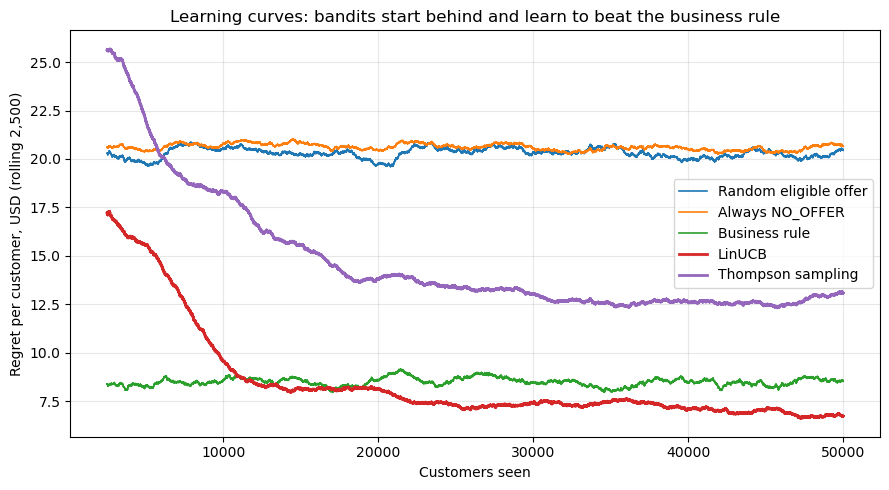

In [6]:
window = 2_500
plt.figure(figsize=(9, 5))
for name in ["Random eligible offer", "Always NO_OFFER", "Business rule", "LinUCB", "Thompson sampling"]:
    curve = np.mean([pd.Series(r["regret"]).rolling(window).mean() for r in runs[name]], axis=0)
    plt.plot(curve, label=name, lw=2 if name in ("LinUCB", "Thompson sampling") else 1.2)
plt.xlabel("Customers seen"); plt.ylabel(f"Regret per customer, USD (rolling {window:,})")
plt.title("Learning curves: bandits start behind and learn to beat the business rule")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
os.makedirs("artifacts", exist_ok=True); plt.savefig("artifacts/bandit_learning_curves.png", dpi=130); plt.show()

## 4. Value of the final learned policy (noise-free)

After training, freeze each bandit and act greedily. Using the simulator's true expected values,
we can measure each policy's value exactly, without outcome noise.

In [7]:
def policy_value(choice):
    return env["expected"][np.arange(len(choice)), choice].mean()

def greedy_choice(learner):
    scores = learner.greedy(env["X"]).T
    return np.where(env["eligible"], scores, -np.inf).argmax(1)

oracle_choice = env["expected"].argmax(1)
rule = RulePolicy()
choices = {
    "Always NO_OFFER": np.zeros(len(pool), int),
    "Business rule": np.array([rule.select(i, env["X"][i], env["eligible"][i]) for i in range(len(pool))]),
    **{f"{name} (learned)": greedy_choice(l) for name, l in learners.items()},
    "Oracle": oracle_choice,
}
values = pd.DataFrame({
    "value_per_customer_usd": {k: policy_value(v) for k, v in choices.items()},
    "agrees_with_oracle": {k: (v == oracle_choice).mean() for k, v in choices.items()},
})
values["gap_to_oracle_usd"] = values.loc["Oracle", "value_per_customer_usd"] - values["value_per_customer_usd"]
values.round(3)

,value_per_customer_usd,agrees_with_oracle,gap_to_oracle_usd
Always NO_OFFER,472.175,0.029,20.530
Business rule,484.257,0.804,8.449
LinUCB (learned),489.720,0.767,2.986
Thompson sampling (learned),475.303,0.276,17.402
Oracle,492.705,1.000,0.000


In [8]:
best_learner = max(learners, key=lambda n: policy_value(choices[f"{n} (learned)"]))
learned = choices[f"{best_learner} (learned)"]
mix = pd.DataFrame({
    "segment": env["segment"],
    "learned_offer": [ARMS[a] for a in learned],
    "oracle_offer": [ARMS[a] for a in oracle_choice],
})
print(f"Offer mix by segment — {best_learner} (learned) vs oracle\n")
pd.concat({"learned": pd.crosstab(mix["segment"], mix["learned_offer"]),
           "oracle": pd.crosstab(mix["segment"], mix["oracle_offer"])}, axis=1).fillna(0).astype(int)

Offer mix by segment — LinUCB (learned) vs oracle



learned                                                 oracle  \
        ADDON_TRIAL CONTRACT_UPGRADE LOYALTY_DISCOUNT NO_OFFER ADDON_TRIAL   
segment                                                                      
0                 0               56               10        0          12   
1                69              196                0      101           0   
2                17               11                7        0          13   
3                 6              226                2        0           0   
4                60              533                0        9           6   

                                   
        CONTRACT_UPGRADE NO_OFFER  
segment                            
0                     46        8  
1                    363        3  
2                      7       15  
3                    229        5  
4                    589        7

## 5. Business impact and saved results

In [9]:
n_at_risk = len(pool)
value_rule = values.loc["Business rule", "value_per_customer_usd"]
value_learned = values.loc[f"{best_learner} (learned)", "value_per_customer_usd"]
value_none = values.loc["Always NO_OFFER", "value_per_customer_usd"]
summary = {
    "at_risk_customers": n_at_risk,
    "best_learner": best_learner,
    "annual_lift_vs_no_offer_usd": round((value_learned - value_none) * n_at_risk),
    "annual_lift_vs_business_rule_usd": round((value_learned - value_rule) * n_at_risk),
    "agreement_with_oracle": round(float((learned == oracle_choice).mean()), 3),
    "assumptions": ASSUMPTIONS,
}
print(json.dumps(summary, indent=2))

learner = learners[best_learner]
theta = np.einsum("kij,kj->ki", learner.A_inv, learner.b)
json.dump({"arms": ARMS, "feature_names": env["feature_names"], "theta": theta.round(5).tolist(),
           "learner": best_learner, "reward_scale_usd": 100}, open("artifacts/bandit_policy.json", "w"), indent=2)
json.dump(summary, open("artifacts/bandit_summary.json", "w"), indent=2)

os.makedirs("docs", exist_ok=True)
with open("docs/bandit_results.md", "w") as f:
    f.write("# RetainAI — Offer Optimization Results (simulation)\n\n")
    f.write(f"At-risk customers: {n_at_risk:,} | {T:,} simulated arrivals x {len(SEEDS)} seeds\n\n")
    f.write("## Online learning\n\n" + results.round(2).to_markdown() + "\n\n")
    f.write("## Final learned policy (noise-free)\n\n" + values.round(3).to_markdown() + "\n\n")
    f.write("## Simulator assumptions\n\n" + pd.Series(ASSUMPTIONS, name="value").to_frame().to_markdown() + "\n")
print("Saved artifacts/bandit_policy.json, artifacts/bandit_summary.json, docs/bandit_results.md")

{
  "at_risk_customers": 1303,
  "best_learner": "LinUCB",
  "annual_lift_vs_no_offer_usd": 22861,
  "annual_lift_vs_business_rule_usd": 7118,
  "agreement_with_oracle": 0.767,
  "assumptions": {
    "horizon_months": 12,
    "causal_shrinkage": 0.5,
    "accept_addon_trial": 0.6,
    "accept_contract_new": 0.25,
    "accept_contract_tenured": 0.45,
    "accept_discount": 1.0,
    "addon_cost_per_month": 8.0,
    "contract_discount_pct": 10,
    "discount_months": 6
  }
}
Saved artifacts/bandit_policy.json, artifacts/bandit_summary.json, docs/bandit_results.md
